os.getcwd():  /home/kimbring2/jetbot/notebooks/generative_ai


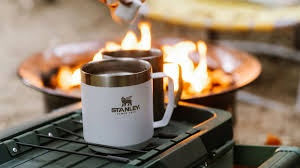

In [1]:
from IPython.display import display, HTML, clear_output
from IPython.display import Image as IPython_Image
import PIL.Image
import os
import cv2
import numpy as np

print("os.getcwd(): ", os.getcwd())

def arrayShow(imageArray):
    image = bytes(cv2.imencode('.jpg', imageArray)[1])
    return IPython_Image(data=image)

# Read image and run image encoder
pil_image = PIL.Image.open("/home/kimbring2/nanoowl/assets/cup_image.jpg")
open_cv_image = np.array(pil_image)
open_cv_image = open_cv_image[:, :, ::-1].copy()

arrayShow(open_cv_image)

/home/kimbring2/.local/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[01/26/2024-16:14:16] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
['an cup', ' a face']


/home/kimbring2/nanoowl/nanoowl/image_preprocessor.py:71: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  image = torch.from_numpy(np.asarray(image))


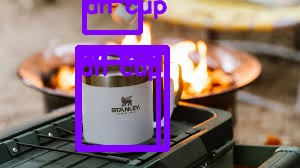

In [3]:
import PIL.Image
import time
import torch
from nanoowl.owl_predictor import (OwlPredictor)
from nanoowl.owl_drawing import (draw_owl_output)
import numpy as np
from IPython.display import display, HTML, clear_output
from IPython.display import Image as IPython_Image
import PIL.Image
import os
import cv2
import numpy as np


def arrayShow(imageArray):
    image = bytes(cv2.imencode('.jpg', imageArray)[1])
    return IPython_Image(data=image)


model = "google/owlvit-base-patch32"
image_encoder_engine = "/home/kimbring2/nanoowl/data/owl_image_encoder_patch32.engine"
predictor = OwlPredictor(model, image_encoder_engine=image_encoder_engine)

image = "/home/kimbring2/nanoowl/assets/cup_image.jpg"
prompt = "[an cup, a face]"
threshold = 0.1
output = "owl_predict_out.jpg"
num_profiling_runs = 30

prompt = prompt.strip("][()")
text = prompt.split(',')
print(text)
image = PIL.Image.open(image)
text_encodings = predictor.encode_text(text)
output = predictor.predict(image=image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)

pil_image = draw_owl_output(image, output, text=text, draw_text=True)

open_cv_image = np.array(pil_image)
open_cv_image = open_cv_image[:, :, ::-1].copy()

arrayShow(open_cv_image)

['a thumb']


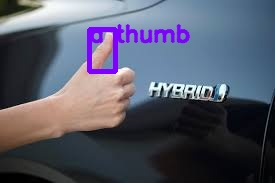

In [19]:
image = "/home/kimbring2/nanoowl/assets/thumb_image.jpg"
prompt = "[a thumb]"
threshold = 0.1
output = "owl_predict_out.jpg"
num_profiling_runs = 30

prompt = prompt.strip("][()")
text = prompt.split(',')
print(text)
image = PIL.Image.open(image)

text_encodings = predictor.encode_text(text)
output = predictor.predict(image=image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)

pil_image = draw_owl_output(image, output, text=text, draw_text=True)

open_cv_image = np.array(pil_image)
open_cv_image = open_cv_image[:, :, ::-1].copy()

arrayShow(open_cv_image)

['a thumb']


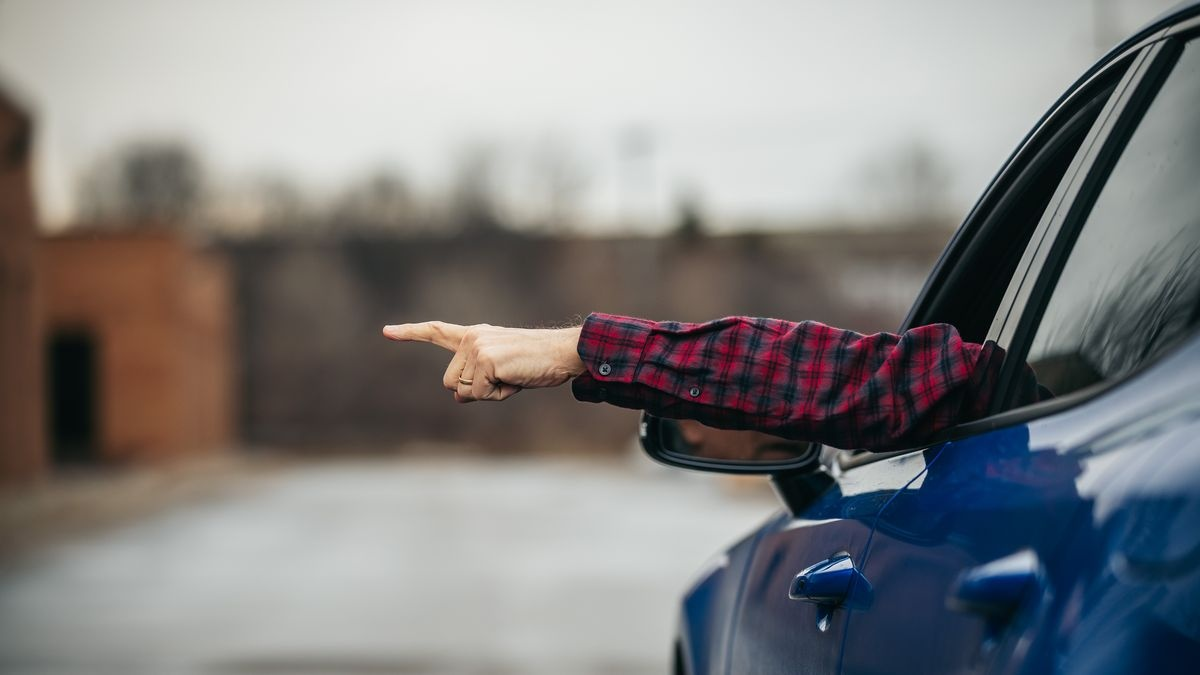

In [24]:
image = "/home/kimbring2/nanoowl/assets/index_finger_image.jpg"
prompt = "[a thumb]"
threshold = 0.1
output = "owl_predict_out.jpg"
num_profiling_runs = 30

prompt = prompt.strip("][()")
text = prompt.split(',')
print(text)
image = PIL.Image.open(image)

text_encodings = predictor.encode_text(text)
output = predictor.predict(image=image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)

pil_image = draw_owl_output(image, output, text=text, draw_text=True)

open_cv_image = np.array(pil_image)
open_cv_image = open_cv_image[:, :, ::-1].copy()

arrayShow(open_cv_image)

In [ ]:
import cv2
from matplotlib import pyplot as plt
from PIL import Image


def gstreamer_pipeline(sensor_id=0, capture_width=1920, capture_height=1080, display_width=960, display_height=540, framerate=30, 
                       flip_method=0,):
    return (
        "nvarguscamerasrc sensor-id=%d ! "
        "video/x-raw(memory:NVMM), width=(int)%d, height=(int)%d, framerate=(fraction)%d/1 ! "
        "nvvidconv flip-method=%d ! "
        "video/x-raw, width=(int)%d, height=(int)%d, format=(string)BGRx ! "
        "videoconvert ! "
        "video/x-raw, format=(string)BGR ! appsink"
        % (sensor_id, capture_width, capture_height, framerate, flip_method, display_width, display_height))


def show_camera():
    path_raw_video = '/home/kimbring2/Desktop/raw_video.avi'
    
    fps = 15
    raw_video_out = cv2.VideoWriter(path_raw_video, cv2.VideoWriter_fourcc(*'DIVX'), fps, (1180,760))

    # To flip the image, modify the flip_method parameter (0 and 2 are the most common)
    video_capture = cv2.VideoCapture(gstreamer_pipeline(flip_method=0), cv2.CAP_GSTREAMER)
    frame_num = 0
    
    print("video_capture.isOpened(): ",  video_capture.isOpened())
    if video_capture.isOpened():
        try:
            while True:
                ret_val, frame = video_capture.read()
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                #if frame != None:
                print("frame.shape: ", frame.shape)
                print("ret_val: ", ret_val)
                
                print("frame_num: ", frame_num)
                
                frame = cv2.resize(frame, (1180, 760), interpolation=cv2.INTER_AREA)
                print("frame.shape: ", frame.shape)
                #raw_video_out.write(frame)
                
                image = Image.fromarray(frame)
                
                output = predictor.predict(image=image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)
                pil_image = draw_owl_output(image, output, text=text, draw_text=True)
                
                open_cv_image = np.array(pil_image)
                open_cv_image = open_cv_image[:, :, ::-1].copy()
                #cv2.imwrite("output.png", open_cv_image)
                
                raw_video_out.write(open_cv_image)
                #arrayShow(open_cv_image)  
                
                frame_num += 1

                #break
        finally:
            video_capture.release()
    else:
        print("Error: Unable to open camera")

show_camera()

GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 0 
   Camera mode  = 2 
   Output Stream W = 1920 H = 1

[ WARN:0] global /home/ubuntu/build_opencv/opencv/modules/videoio/src/cap_gstreamer.cpp (1100) open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  1
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  2
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  3
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  4
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  5
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  6
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  7
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  8
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  9
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  10
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num:  11
frame.shape:  (760, 1180, 3)
frame.shape:  (540, 960, 3)
ret_val:  True
frame_num